# KarmaDock 虚拟筛选教程

本 notebook 只保留 **节点 / 坐标位移去噪** 这条技术路线。

统一约定：
- 骨架统一为 `nn.Linear() + nn.ReLU()`
- 训练输出统一展示 loss history
- 结果区只保留家族主指标 `RMSD < 2A`

In [1]:
import copy
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt

%matplotlib inline
warnings.filterwarnings("ignore")
RDLogger.DisableLog("rdApp.*")

_root = Path(".").resolve()
while not (_root / "demo_data").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

PROJECT_ROOT = _root
DATA_DIR = PROJECT_ROOT / "demo_data"
CORESET_FILE = DATA_DIR / "CoreSet.dat"
COMPLEX_DIR = DATA_DIR / "coreset"

from teaching_demos.common import (
    ATOM_FEAT_DIM, atom_features, build_mlp, compute_rmsd,
    describe_model_parameters, history_frame, load_complex,
    metric_frame, parse_pdb_ids, plot_loss_curves,
)

## 1. 超参数设置

| 参数 | 教学值 | 原始值 | 说明 |
|------|--------|--------|------|
| `DISTANCE_CUTOFF` | 8.0 Å | — | 交互图边的距离阈值 |
| `N_EGNN_LAYERS` | 4 | 8 | 每轮 recycle 内的 EGNN 层数 |
| `N_RECYCLES` | 2 | 3 | 多次循环实现"粗调 → 细调" |
| `NOISE_TR_SIGMA` | 4.0 Å | 4.0 | 配体平移噪声标准差（匹配原始 `shuffle_center(noise=4)`） |
| `HIDDEN_DIM` | 128 | 128 | 隐层维度（与原始一致） |

> **教学简化说明**：原始 KarmaDock 使用 6 层 GraphTransformer 编码配体、GVP 编码蛋白质、
> 8 个 EGNN 层 × 3 轮 recycle = 24 次 EGNN 传递，并带有 Gate 残差连接和 MDN 打分头。
> 本教程将编码器简化为 MLP（`nn.Linear + nn.ReLU`），EGNN 层简化为基础消息传递 + 等变坐标更新，
> 但保留了核心技术路线：E(n) 等变坐标位移 + recycle 迭代精炼。

In [2]:
DISTANCE_CUTOFF = 8.0
N_EGNN_LAYERS = 4
N_RECYCLES = 2
NOISE_TR_SIGMA = 4.0
HIDDEN_DIM = 128
N_EPOCHS = 200
LR = 1e-3
BATCH_SIZE = 1
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
np.random.seed(SEED)

display(pd.DataFrame({
    '超参数': ['DISTANCE_CUTOFF', 'N_EGNN_LAYERS', 'N_RECYCLES', 'NOISE_TR_SIGMA',
              'HIDDEN_DIM', 'N_EPOCHS', 'LR', 'DEVICE'],
    '教学值': [f'{DISTANCE_CUTOFF} A', N_EGNN_LAYERS, N_RECYCLES, f'{NOISE_TR_SIGMA} A',
           HIDDEN_DIM, N_EPOCHS, LR, str(DEVICE)],
    '原始值': ['—', 8, 3, '4.0 A', 128, '—', '—', '—'],
    '说明': ['蛋白-配体原子对建边距离上限', 'EGNN 消息传递层数', '循环精炼次数（共享参数）',
             '配体平移噪声标准差', '隐层维度', '训练轮数', '学习率', '计算设备']
}))
print(f"总 EGNN 传递次数: {N_EGNN_LAYERS} layers x {N_RECYCLES} recycles = {N_EGNN_LAYERS * N_RECYCLES} passes")
print(f"原始 KarmaDock: 8 layers x 3 recycles = 24 passes")

,超参数,教学值,原始值,说明
0,DISTANCE_CUTOFF,8.0 A,—,蛋白-配体原子对建边距离上限
1,N_EGNN_LAYERS,4,8,EGNN 消息传递层数
2,N_RECYCLES,2,3,循环精炼次数（共享参数）
3,NOISE_TR_SIGMA,4.0 A,4.0 A,配体平移噪声标准差
4,HIDDEN_DIM,128,128,隐层维度
5,N_EPOCHS,200,—,训练轮数
6,LR,0.001,—,学习率
7,DEVICE,cuda,—,计算设备


总 EGNN 传递次数: 4 layers x 2 recycles = 8 passes
原始 KarmaDock: 8 layers x 3 recycles = 24 passes


## 2. 数据加载与特征提取

使用 **PDBbind CASF-2016 核心集**（demo_data 中包含 20 个复合物子集）。

**对接模型的输入构象**：
- 原始 KarmaDock 使用 RDKit `AllChem.EmbedMolecule()` + MMFF 力场优化生成初始 3D 构象
- 该构象与晶体构象具有**不同的内部几何**（键长、键角、扭转角），平均 RMSD 约 1.5 Å
- 训练时在 RDKit 构象上施加随机旋转 + 随机平移（std=4 Å），模拟"未知初始位姿"
- 模型学习从 RDKit 构象出发，恢复晶体结合构象

> **注意**：这与简单的"刚体去噪"不同——模型需要同时调整**内部几何**和**全局位姿**。

In [3]:
def generate_rdkit_conformer(mol):
    """用 RDKit 生成初始 3D 构象（模拟 KarmaDock 的 mol2conformer_v1）。

    流程：移除已有构象 -> 加氢 -> EmbedMolecule -> MMFF 力场优化 -> 去氢。
    生成的构象与晶体构象有不同的内部几何，这正是对接任务的核心挑战。
    """
    mol_copy = copy.deepcopy(mol)
    mol_copy.RemoveAllConformers()
    mol_h = Chem.AddHs(mol_copy)
    result = AllChem.EmbedMolecule(mol_h)
    if result == -1:
        return None
    try:
        AllChem.MMFFOptimizeMolecule(mol_h, mmffVariant='MMFF94s')
    except Exception:
        pass
    mol_h = Chem.RemoveHs(mol_h)
    return mol_h.GetConformer().GetPositions().astype(np.float32)


def add_noise_to_ligand(coords):
    """对配体坐标施加随机旋转 + 平移噪声，模拟未知初始位姿。

    匹配原始 KarmaDock 的 shuffle_center(noise=4) + random_rotation()。
    """
    coords = coords.copy()
    center = coords.mean(axis=0)
    R = Rotation.random().as_matrix().astype(np.float32)
    coords = (coords - center) @ R.T + center
    coords += np.random.randn(1, 3).astype(np.float32) * NOISE_TR_SIGMA
    return coords


pdb_ids = parse_pdb_ids(CORESET_FILE)
print(f"从 CoreSet.dat 读取到 {len(pdb_ids)} 个复合物")

all_data = []
rdkit_fail_count = 0
for pdbid in sorted(pdb_ids):
    cplx = load_complex(pdbid, COMPLEX_DIR)
    prot_mol, lig_mol = cplx["prot_mol"], cplx["lig_mol"]
    prot_coords = cplx["prot_coords"]
    lig_coords_crystal = cplx["lig_coords"]  # 晶体构象（标签）
    prot_feats = np.array([atom_features(a) for a in prot_mol.GetAtoms()], dtype=np.float32)
    lig_feats = np.array([atom_features(a) for a in lig_mol.GetAtoms()], dtype=np.float32)

    # 生成 RDKit 初始构象（模拟原始 KarmaDock 的 mol2conformer_v1）
    lig_coords_rdkit = generate_rdkit_conformer(lig_mol)
    if lig_coords_rdkit is None:
        lig_coords_rdkit = lig_coords_crystal.copy()
        rdkit_fail_count += 1

    # 将 RDKit 构象中心对齐到晶体构象中心（模拟原始的 pocket_center 对齐）
    lig_coords_rdkit += lig_coords_crystal.mean(axis=0) - lig_coords_rdkit.mean(axis=0)

    all_data.append((prot_coords, prot_feats, lig_coords_crystal, lig_coords_rdkit, lig_feats))

print(f"成功加载 {len(all_data)} 个复合物（RDKit 构象生成失败: {rdkit_fail_count}）")

# 展示 RDKit 构象与晶体构象的差异
rdkit_rmsds = [compute_rmsd(d[3], d[2]) for d in all_data]
print(f"RDKit 构象 vs 晶体构象 RMSD: 均值 {np.mean(rdkit_rmsds):.2f} A, "
      f"最大 {np.max(rdkit_rmsds):.2f} A, 最小 {np.min(rdkit_rmsds):.2f} A")

sample = all_data[0]
display(pd.DataFrame({
    '数据': ['蛋白坐标', '蛋白特征', '配体晶体坐标', 'RDKit 初始构象', '配体特征'],
    '形状': [str(sample[0].shape), str(sample[1].shape),
             str(sample[2].shape), str(sample[3].shape), str(sample[4].shape)],
    '说明': [f'{sample[0].shape[0]} 个蛋白原子 x 3D 坐标',
             f'{sample[1].shape[0]} 个蛋白原子 x {sample[1].shape[1]} 维特征',
             f'{sample[2].shape[0]} 个配体原子 x 3D 坐标（标签）',
             f'{sample[3].shape[0]} 个配体原子 x 3D 坐标（模型输入基础）',
             f'{sample[4].shape[0]} 个配体原子 x {sample[4].shape[1]} 维特征']
}))

从 CoreSet.dat 读取到 20 个复合物
成功加载 20 个复合物（RDKit 构象生成失败: 0）
RDKit 构象 vs 晶体构象 RMSD: 均值 6.05 A, 最大 11.03 A, 最小 0.51 A


,数据,形状,说明
0,蛋白坐标,"(614, 3)",614 个蛋白原子 x 3D 坐标
1,蛋白特征,"(614, 10)",614 个蛋白原子 x 10 维特征
2,配体晶体坐标,"(36, 3)",36 个配体原子 x 3D 坐标（标签）
3,RDKit 初始构象,"(36, 3)",36 个配体原子 x 3D 坐标（模型输入基础）
4,配体特征,"(36, 10)",36 个配体原子 x 10 维特征


## 3. 数据集与数据加载器

对接模型数据集的核心设计：
- **标签是坐标矩阵**：与打分模型不同，对接模型的标签是配体的晶体 3D 坐标
- **输入是 RDKit 构象**：而非晶体构象，模型需要同时修正内部几何和全局位姿
- **动态加噪**：每次 `__getitem__` 时对 RDKit 构象施加不同的随机旋转 + 平移，相当于数据增强
- **BATCH_SIZE=1**：变长图，逐样本处理

In [4]:
class DockingDataset(Dataset):
    def __init__(self, data_list, add_noise=True):
        self.data = data_list
        self.add_noise = add_noise

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        prot_coords, prot_feats, lig_coords_crystal, lig_coords_rdkit, lig_feats = self.data[idx]
        # 输入：RDKit 构象 + 随机噪声（非晶体构象）
        if self.add_noise:
            lig_coords_input = add_noise_to_ligand(lig_coords_rdkit)
        else:
            lig_coords_input = lig_coords_rdkit.copy()
        # 标签：晶体构象
        return (torch.FloatTensor(prot_coords),
                torch.FloatTensor(prot_feats),
                torch.FloatTensor(lig_coords_input),
                torch.FloatTensor(lig_coords_crystal),
                torch.FloatTensor(lig_feats))


indices = np.random.permutation(len(all_data))
split = int(0.8 * len(all_data))
train_data = [all_data[i] for i in indices[:split]]
test_data = [all_data[i] for i in indices[split:]]

train_loader = DataLoader(DockingDataset(train_data, add_noise=True),
                          batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(DockingDataset(test_data, add_noise=True),
                         batch_size=BATCH_SIZE, shuffle=False)

display(pd.DataFrame({
    '数据集': ['训练集', '测试集', '总计'],
    '样本数': [len(train_data), len(test_data), len(all_data)],
    '比例': [f'{len(train_data)/len(all_data):.0%}',
             f'{len(test_data)/len(all_data):.0%}', '100%']
}))

,数据集,样本数,比例
0,训练集,16,80%
1,测试集,4,20%
2,总计,20,100%


## 4. 模型架构

本节保留 **KarmaDock 的核心技术路线**：EGNN 等变坐标位移 + recycle 迭代精炼。

```
RDKit 初始构象（加噪后）+ 蛋白坐标 + 原子特征
  → 蛋白/配体 MLP 嵌入
  → 拼接为统一交互图
  → [Recycle x N_RECYCLES]:
      [EGNN x N_EGNN_LAYERS]:
          → 消息传递（节点对特征 + 原子间距离）
          → 节点特征更新
          → 等变坐标更新：delta = normalize(pos_i - pos_j) * scalar_weight
      → 重建交互图边（坐标已变化）
  → 输出配体预测坐标
```

**核心创新 — E(n) 等变坐标更新**：
- 原始 EGNN（`EGNN_Block.py` 的 `coords_update` 类）：坐标位移沿**相对位置方向**，乘以**标量权重**
- 即 `delta_x = (pos_i - pos_j) / ||pos_i - pos_j|| * f(attention)`
- 标量权重由学习得到，方向由几何决定 → 对输入的旋转/平移等变
- 教学版简化：去掉多头注意力和 GraphNorm，保留等变位移机制

In [5]:
class ToyEGNNLayer(nn.Module):
    """简化版 EGNN 层：保留等变坐标更新核心机制。

    原始 EGNN 使用多头注意力 + GraphNorm（EGNN_Block.py）。
    教学版简化为 MLP 聚合，但关键保留：
    坐标位移 = normalize(pos_i - pos_j) * scalar_weight，满足 E(n) 等变性。
    """

    def __init__(self, hidden_dim):
        super().__init__()
        self.msg_mlp = build_mlp(hidden_dim * 2 + 1, hidden_dim, hidden_dim)
        self.node_mlp = build_mlp(hidden_dim * 2, hidden_dim, hidden_dim)
        self.coord_mlp = build_mlp(hidden_dim, hidden_dim // 2, 1)

    def forward(self, h, coords, edge_index, n_prot):
        i, j = edge_index
        diff = coords[i] - coords[j]
        dist = diff.norm(dim=-1, keepdim=True).clamp(min=1e-6)

        # 消息传递：融合节点对特征 + 距离
        m_ij = self.msg_mlp(torch.cat([h[i], h[j], dist * 0.1], dim=-1))
        agg = torch.zeros_like(h)
        agg.index_add_(0, i, m_ij)
        counts = torch.zeros(h.size(0), 1, device=h.device)
        counts.index_add_(0, i, torch.ones(i.size(0), 1, device=h.device))
        agg = agg / counts.clamp(min=1)

        # 节点特征更新
        h_new = self.node_mlp(torch.cat([h, agg], dim=-1))

        # 等变坐标更新：位移沿相对位置方向（只更新配体原子）
        direction = diff / dist  # 单位方向向量
        weight = self.coord_mlp(m_ij)  # 标量权重
        delta = torch.zeros_like(coords)
        delta.index_add_(0, i, direction * weight)
        delta[:n_prot] = 0  # 蛋白坐标不动

        return h_new, coords + delta


class ToyKarmaDock(nn.Module):
    """保留 EGNN 坐标位移 + recycle 路线，骨架只用 Linear + ReLU。"""

    def __init__(self, atom_dim=ATOM_FEAT_DIM, hidden_dim=HIDDEN_DIM,
                 n_layers=N_EGNN_LAYERS, n_recycles=N_RECYCLES):
        super().__init__()
        self.n_recycles = n_recycles
        self.prot_embed = build_mlp(atom_dim, hidden_dim, hidden_dim)
        self.lig_embed = build_mlp(atom_dim, hidden_dim, hidden_dim)
        self.egnn_layers = nn.ModuleList([
            ToyEGNNLayer(hidden_dim) for _ in range(n_layers)
        ])

    def _build_edges(self, coords, n_prot):
        """构建交互图边：蛋白-配体 + 配体-配体（距离阈值内）。"""
        dist = torch.cdist(coords, coords)
        i, j = torch.where((dist < DISTANCE_CUTOFF) & (dist > 0.1))
        # 保留涉及配体的边（蛋白-配体、配体-蛋白、配体-配体）
        mask = (i >= n_prot) | (j >= n_prot)
        return torch.stack([i[mask], j[mask]], dim=0)

    def forward(self, prot_coords, prot_feats, lig_noisy, lig_feats):
        prot_h = self.prot_embed(prot_feats)
        lig_h = self.lig_embed(lig_feats)
        n_prot = prot_h.size(0)

        # 拼接为统一图
        h = torch.cat([prot_h, lig_h], dim=0)
        coords = torch.cat([prot_coords, lig_noisy], dim=0)

        # Recycle: 多轮 EGNN 迭代（粗调 -> 细调）
        for _ in range(self.n_recycles):
            edge_index = self._build_edges(coords, n_prot)
            for layer in self.egnn_layers:
                h, coords = layer(h, coords, edge_index, n_prot)

        return coords[n_prot:]  # 返回配体坐标


model = ToyKarmaDock(atom_dim=ATOM_FEAT_DIM, hidden_dim=HIDDEN_DIM).to(DEVICE)
display(describe_model_parameters(model))

,层名称,形状,参数量
0,prot_embed.0.weight,"(128, 10)",1280
1,prot_embed.0.bias,"(128,)",128
2,prot_embed.2.weight,"(128, 128)",16384
3,prot_embed.2.bias,"(128,)",128
4,lig_embed.0.weight,"(128, 10)",1280
5,lig_embed.0.bias,"(128,)",128
6,lig_embed.2.weight,"(128, 128)",16384
7,lig_embed.2.bias,"(128,)",128
8,egnn_layers.0.msg_mlp.0.weight,"(128, 257)",32896
9,egnn_layers.0.msg_mlp.0.bias,"(128,)",128


## 5. 训练

训练流程：
1. 每个样本：在 RDKit 构象上加随机噪声（旋转 + 平移）作为模型输入
2. 模型通过 EGNN recycle 迭代，预测配体原子的晶体坐标
3. 损失：预测坐标与晶体坐标的 MSE（等价于 RMSD² 的无偏估计）

In [6]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
train_loss_history = []
val_loss_history = []

print(f"训练 {N_EPOCHS} 轮...\n")

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    epoch_losses = []
    for prot_coords, prot_feats, lig_noisy, lig_true, lig_feats in train_loader:
        prot_coords = prot_coords.squeeze(0).to(DEVICE)
        prot_feats = prot_feats.squeeze(0).to(DEVICE)
        lig_noisy = lig_noisy.squeeze(0).to(DEVICE)
        lig_true = lig_true.squeeze(0).to(DEVICE)
        lig_feats = lig_feats.squeeze(0).to(DEVICE)
        lig_pred = model(prot_coords, prot_feats, lig_noisy, lig_feats)
        # use MSE for backprop
        loss_bp = ((lig_pred - lig_true) ** 2).mean()
        optimizer.zero_grad()
        loss_bp.backward()
        optimizer.step()
        epoch_losses.append(loss_bp.item())

    model.eval()
    val_losses = []
    with torch.no_grad():
        for prot_coords, prot_feats, lig_noisy, lig_true, lig_feats in test_loader:
            prot_coords = prot_coords.squeeze(0).to(DEVICE)
            prot_feats = prot_feats.squeeze(0).to(DEVICE)
            lig_noisy = lig_noisy.squeeze(0).to(DEVICE)
            lig_true = lig_true.squeeze(0).to(DEVICE)
            lig_feats = lig_feats.squeeze(0).to(DEVICE)
            lig_pred = model(prot_coords, prot_feats, lig_noisy, lig_feats)
            val_losses.append(((lig_pred - lig_true) ** 2).mean().item())

    train_loss = float(np.mean(epoch_losses))
    val_loss = float(np.mean(val_losses))
    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)
    if epoch == 1 or epoch % 20 == 0:
        print(f"Epoch {epoch:>3d}/{N_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

history_df = history_frame(train_loss_history, val_loss_history)

训练 200 轮...

Epoch   1/200 | Train Loss: 25.2173 | Val Loss: 22.3694
Epoch  20/200 | Train Loss: 20.0777 | Val Loss: 17.2874
Epoch  40/200 | Train Loss: 23.4462 | Val Loss: 22.7955
Epoch  60/200 | Train Loss: 24.7387 | Val Loss: 17.9360
Epoch  80/200 | Train Loss: 19.2620 | Val Loss: 21.5384
Epoch 100/200 | Train Loss: 18.0073 | Val Loss: 26.3763
Epoch 120/200 | Train Loss: 19.2364 | Val Loss: 15.5334
Epoch 140/200 | Train Loss: 20.1336 | Val Loss: 23.4283
Epoch 160/200 | Train Loss: 23.1934 | Val Loss: 47.9956
Epoch 180/200 | Train Loss: 21.3560 | Val Loss: 84.1672
Epoch 200/200 | Train Loss: 21.9131 | Val Loss: 18.8968


## 6. 评估与可视化

- 统一展示训练的 loss history。
- 结果区只保留家族主指标：`RMSD < 2A`。

> **注意**：原始 KarmaDock 的评估流程区分 uncorrected / FF-corrected / aligned-corrected 三种 RMSD，
> 并做 3 次重复统计。本教程仅展示单次未校正 RMSD，作为教学简化。

In [7]:
model.eval()
test_rmsds = []

with torch.no_grad():
    for prot_coords, prot_feats, lig_noisy, lig_true, lig_feats in test_loader:
        prot_coords = prot_coords.squeeze(0).to(DEVICE)
        prot_feats = prot_feats.squeeze(0).to(DEVICE)
        lig_noisy = lig_noisy.squeeze(0).to(DEVICE)
        lig_true_np = lig_true.squeeze(0).numpy()
        lig_feats = lig_feats.squeeze(0).to(DEVICE)
        lig_pred = model(prot_coords, prot_feats, lig_noisy, lig_feats)
        test_rmsds.append(compute_rmsd(lig_pred.cpu().numpy(), lig_true_np))

test_rmsds = np.asarray(test_rmsds, dtype=np.float32)
success_rate = float((test_rmsds < 2.0).mean() * 100.0)
display(metric_frame([("RMSD < 2A", f"{success_rate:.1f}%")]))

,指标,值
0,RMSD < 2A,0.0%


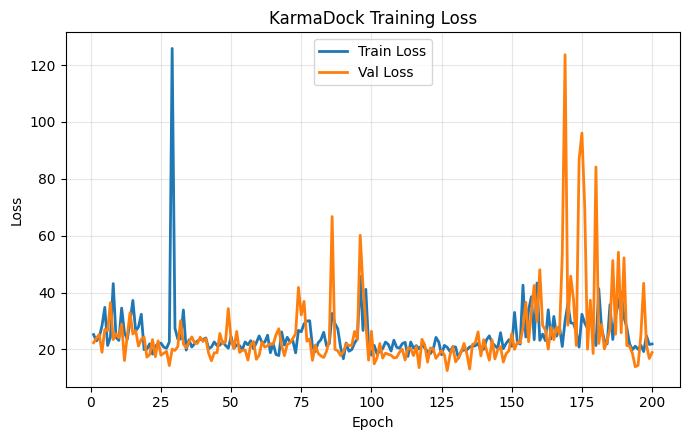

In [8]:
plot_loss_curves(train_loss_history, val_loss_history, title="KarmaDock Training Loss")

## 总结

- 技术路线：保留 KarmaDock 的 **EGNN 等变坐标位移 + recycle 迭代精炼** 路线。
- 数据：输入为 RDKit 生成的初始构象（非晶体构象），标签为晶体结合构象。
- 教学骨架：编码器统一为 `nn.Linear() + nn.ReLU()` 的简单 MLP，EGNN 层保留等变位移核心。
- 训练输出：统一展示 train / val loss history。
- 主指标：`RMSD < 2A`。
- 训练损失未下降：`本notebook简化了分子的表征、模型的架构、训练的超参数，因此训练损失难以下降。完整的实现请参考 https://github.com/schrojunzhang/KarmaDock`